### Answer the questions

**1. Derive an analytical solution to the regression problem. Use a vector form of the equation.<br>**
<br>
При этом значении вектора параметров достигается минимальное значение функции потерь<br>
$$w = (X^TX)^{-1}X^Ty$$<br>
Вывод:
$$L = (Xw - y)(Xw - y)^T$$<br>
$$L = (Xw - y)(X^Tw^T - y^T) = XwX^Tw^T - Xwy^T - yX^Tw^T + y^Ty = $$<br>
Так как $Xwy^T$ — это скаляр, он равен своему транспонированному значению. Следовательно:<br>
$$= XwX^Tw^T - 2Xwy^T + y^Ty$$<br>
Берем градиент и приравниваем к нулю:<br>
$$\frac{dL}{dw} = 2wX^TX - 2Xy^T = 2(wX^TX - Xy^T) = 0$$<br>
$$wX^TX - yX^T = 0$$
$$wX^TX = yX^T$$
$$w = (X^TX)^{-1}yX^T$$

**2. What changes in the solution when L1 and L2 regularizations are added to the loss function.<br>**
<br>
Функция потерь принимает вид:<br>
При Ridge регуляризации:<br>
$$L = (Xw - y)(Xw - y)^T + \lambda w^Tw$$
При Lasso регуляризации:<br>
$$L = (Xw - y)(Xw - y)^T + \lambda \|w\|_1$$
**3. Explain why L1 regularization is often used to select features. Why are there many weights equal to 0 after the model is fit?<br>**
<br>
L1-регуляризация добавляет штраф, равный сумме абсолютных значений весов. В пространстве параметров ограничение образует форму ромба. Линии уровня функции потерь MSE представляют собой эллипсы. Оптимальное решение находится в точке, где эллипс впервые касается ромба. Из-за острых углов на осях касание с большой вероятностью происходит именно в вершине, где одна или несколько координат весов равны нулю. Это эффективно отбирает признаки, исключая те, чьи веса стали нулевыми.<br>
<br>
**4. Explain how you can use the same models (Linear regression, Ridge, etc.) but make it possible to fit nonlinear dependencies.<br>**
Мы можем моделировать нелинейные зависимости, преобразуя наши исходные признаки в новое, более богатое пространство с помощью базисных функций $\phi(x)$. Вместо того чтобы подавать в модель просто $x$, мы подаем набор признаков: $[1, x, x^2, x^3, \dots, x^n]$. Модель принимает вид:$$f(\mathbf{x}) = \mathbf{w}^T \phi(\mathbf{x})$$<br>
Хотя график функции $f(x)$ будет выглядеть как сложная кривая, для алгоритма обучения ничего не меняется. Он по-прежнему просто умножает веса на входные значения и складывает их.

### Introduction — make all the preprocessing staff from the previous lesson

In [209]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, MinMaxScaler

In [210]:
df = pd.read_json('data/train.json')
df.info()

<class 'pandas.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  str    
 3   created          49352 non-null  str    
 4   description      49352 non-null  str    
 5   display_address  49352 non-null  str    
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  str    
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  str    
 14  interest_level   49352 non-null  str    
dtypes: float64(3), int64(3), object(2), str(7)
memory usage: 6.0+ MB


In [211]:
df.columns[df.isna().any()]

Index([], dtype='str')

**Train part**<br>
Боксплот изначальных данных

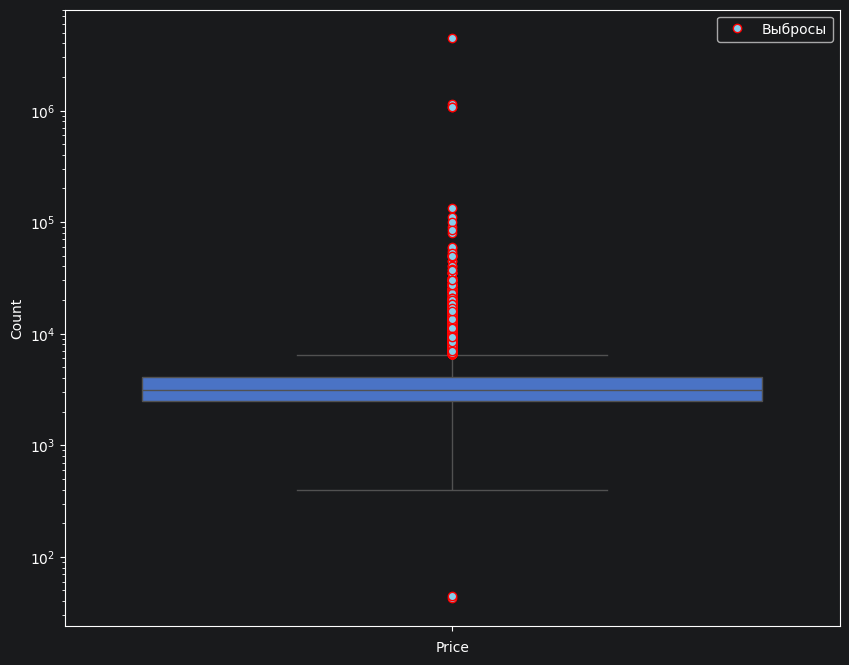

In [212]:
plt.figure(figsize=(10, 8))
sns.boxplot(df['price'], linewidth=1, flierprops=dict(
        marker='o',
        markerfacecolor='skyblue',
        markeredgecolor='red',
        markersize=6,
        label='Выбросы'
    )).set_yscale('log')
plt.xlabel('Price')
plt.ylabel('Count')
plt.legend()
plt.show()

Удалим самые большие и самые низкие выбросы из нашего распределения и построим гистограмму<br>

In [213]:
q1 = df['price'].quantile(0.01)
q99 = df['price'].quantile(0.99)

df = df.loc[(df['price'] >= q1) & (df['price'] <= q99)].reset_index(drop=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48379 entries, 0 to 48378
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        48379 non-null  float64
 1   bedrooms         48379 non-null  int64  
 2   building_id      48379 non-null  str    
 3   created          48379 non-null  str    
 4   description      48379 non-null  str    
 5   display_address  48379 non-null  str    
 6   features         48379 non-null  object 
 7   latitude         48379 non-null  float64
 8   listing_id       48379 non-null  int64  
 9   longitude        48379 non-null  float64
 10  manager_id       48379 non-null  str    
 11  photos           48379 non-null  object 
 12  price            48379 non-null  int64  
 13  street_address   48379 non-null  str    
 14  interest_level   48379 non-null  str    
dtypes: float64(3), int64(3), object(2), str(7)
memory usage: 5.5+ MB


In [214]:
median = df['price'].median()
mode = df['price'].mode().item()
mean = df['price'].mean()

In [215]:
iqr = df['price'].quantile(0.75) - df['price'].quantile(0.25)
iqr.item()

1565.0

In [216]:
q75_line = df['price'].quantile(0.75) + 1.5 * iqr
q25_line = df['price'].quantile(0.25) - 1.5 * iqr

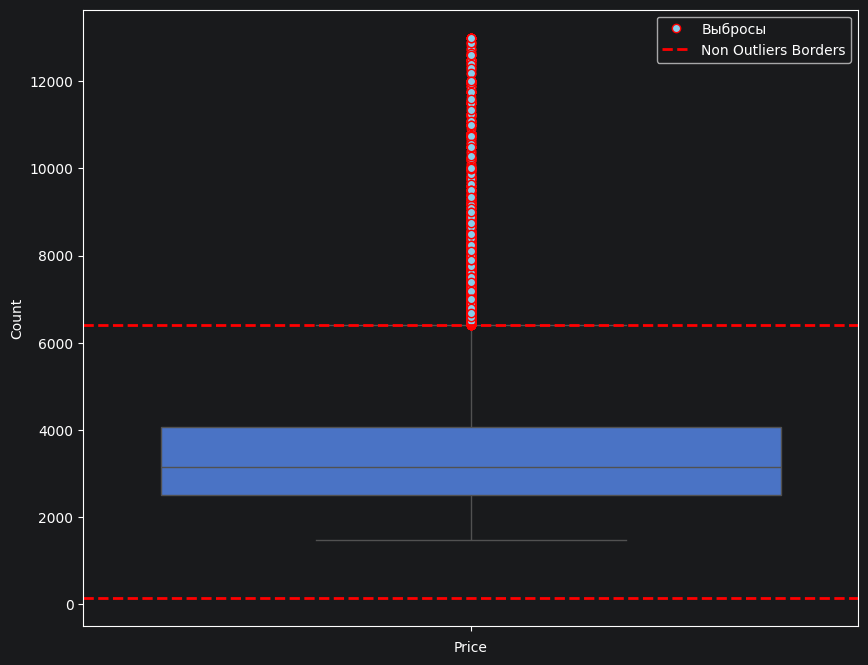

In [217]:
plt.figure(figsize=(10, 8))
sns.boxplot(df['price'], linewidth=1, flierprops=dict(
        marker='o',
        markerfacecolor='skyblue',
        markeredgecolor='red',
        markersize=6,
        label='Выбросы'
    ))
plt.axhline(q75_line, linestyle='--', linewidth=2, color='red', label='Non Outliers Borders')
plt.axhline(q25_line, linestyle='--', linewidth=2, color='red')
plt.xlabel('Price')
plt.ylabel('Count')
plt.legend()
plt.show()

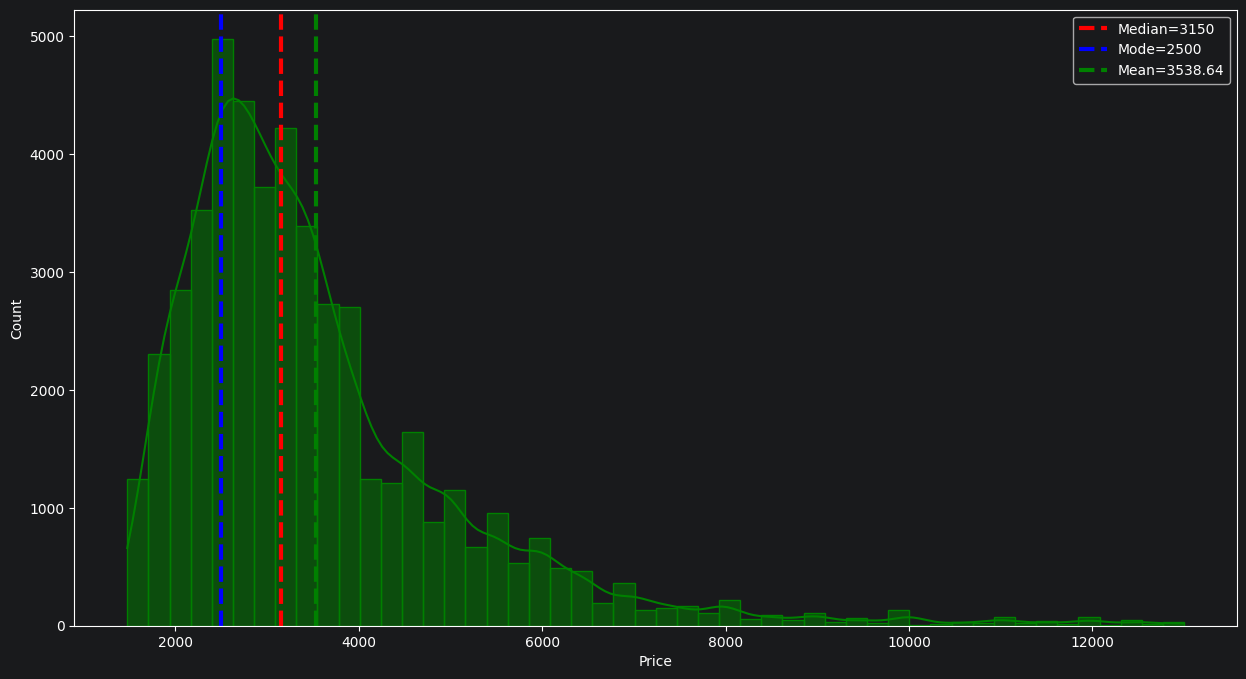

In [218]:
plt.figure(figsize=(15, 8))
sns.histplot(df['price'], bins=50, kde=True, color='green', stat='count', edgecolor='green')
plt.axvline(median, color='red', linestyle='--', linewidth=3, label=f"Median={median:.0f}")
plt.axvline(mode, color='blue', linestyle='--', linewidth=3, label=f"Mode={mode}")
plt.axvline(mean, color='green', linestyle='--', linewidth=3, label=f"Mean={mean:.2f}")
plt.xlabel('Price')
plt.ylabel('Count')
plt.legend()
plt.show()

In [219]:
df['price'].describe()

count    48379.000000
mean      3538.636888
std       1597.663167
min       1475.000000
25%       2500.000000
50%       3150.000000
75%       4065.000000
max      13000.000000
Name: price, dtype: float64

Выбросы, показанные на боксплоте, я удалять не буду, потому что это вполне реальные цены. Нельзя просто так удалить сегмент жилья, пусть и элитного

**Test Part**<br>
Посмотрим на распределение

In [220]:
df_test = pd.read_json('data/test.json')
df_test.info()

<class 'pandas.DataFrame'>
Index: 74659 entries, 0 to 124010
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        74659 non-null  float64
 1   bedrooms         74659 non-null  int64  
 2   building_id      74659 non-null  str    
 3   created          74659 non-null  str    
 4   description      74659 non-null  str    
 5   display_address  74659 non-null  str    
 6   features         74659 non-null  object 
 7   latitude         74659 non-null  float64
 8   listing_id       74659 non-null  int64  
 9   longitude        74659 non-null  float64
 10  manager_id       74659 non-null  str    
 11  photos           74659 non-null  object 
 12  price            74659 non-null  int64  
 13  street_address   74659 non-null  str    
dtypes: float64(3), int64(3), object(2), str(6)
memory usage: 8.5+ MB


In [221]:
df_test['price'].describe()

count    7.465900e+04
mean     3.749033e+03
std      9.713092e+03
min      1.000000e+00
25%      2.495000e+03
50%      3.150000e+03
75%      4.100000e+03
max      1.675000e+06
Name: price, dtype: float64

In [222]:
df_test.columns[df_test.isna().any()]

Index([], dtype='str')

In [223]:
mean_col = np.array([df_test['price'].mean()]  * len(df_test['price']))
d = ((df_test['price'] - mean_col) ** 2).sum() / len(df_test['price'])
d ** (1/2)

np.float64(9713.026562495552)

In [224]:
d = mean_squared_error(df_test['price'], mean_col)
d ** (1/2)

9713.026562495552

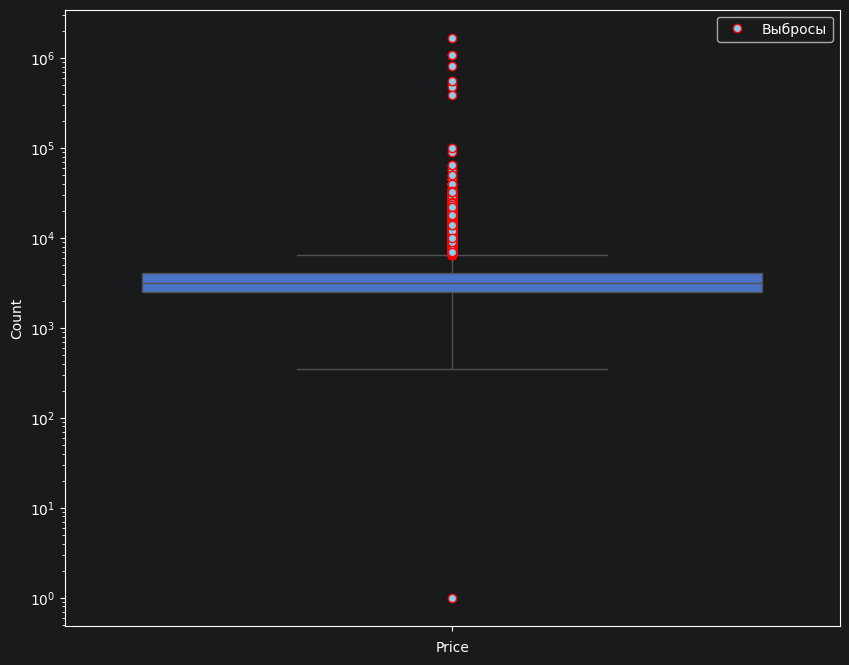

In [225]:
plt.figure(figsize=(10, 8))
sns.boxplot(df_test['price'], linewidth=1, flierprops=dict(
        marker='o',
        markerfacecolor='skyblue',
        markeredgecolor='red',
        markersize=6,
        label='Выбросы'
    )).set_yscale('log')
plt.xlabel('Price')
plt.ylabel('Count')
plt.legend()
plt.show()

В тестовых данных есть явная ошибка в виде единички в стоимости, оставим данные без нее

In [226]:
# df_test = df_test.loc[df_test['price'] > df_test['price'].min()]
# df_test['price'].describe()

Ради интереса оставим данные в пределах 1 и 99 квантилей, чтобы посмотреть, как изменятся метрики самописных моделей

In [227]:
# q1 = df_test['price'].quantile(0.01)
# q99 = df_test['price'].quantile(0.99)
# df_test = df_test.iloc[(df_test['price'] >= q1) & (df_test['price'] <= q99)]
# df_test['price'].describe()

### Intro data analysis part 2

In [228]:
df['features'][df['features'].isna()]

Series([], Name: features, dtype: object)

In [229]:
features_list = []

for _, row in df.iterrows():
    raw_features_str = str(row['features'])
    raw_features_list = re.sub(r'[\[\]\'\"]', '', raw_features_str).strip().split(',')
    raw_features_list = list(map(lambda x: x.strip(), raw_features_list))
    features_list += [feature for feature in raw_features_list]

raw_features_set = set(features_list)

print(f"Кол-во уникальные значений: {len(raw_features_set)}")

counter = Counter(features_list)

print('20 самых популярных характеристик:')
most_common_features = counter.most_common(21)
most_common_features

Кол-во уникальные значений: 1538
20 самых популярных характеристик:


[('Elevator', 25398),
 ('Hardwood Floors', 23159),
 ('Cats Allowed', 23148),
 ('Dogs Allowed', 21662),
 ('Doorman', 20497),
 ('Dishwasher', 20095),
 ('No Fee', 17806),
 ('Laundry in Building', 16093),
 ('Fitness Center', 13000),
 ('Pre-War', 8978),
 ('Laundry in Unit', 8448),
 ('Roof Deck', 6423),
 ('Outdoor Space', 5137),
 ('Dining Room', 4901),
 ('High Speed Internet', 4225),
 ('', 3109),
 ('Balcony', 2898),
 ('Swimming Pool', 2648),
 ('Laundry In Building', 2565),
 ('New Construction', 2507),
 ('Terrace', 2179)]

In [230]:
most_common_features_list = [feature for feature, _ in most_common_features]
print(f'Кол-во самых частых признаков: {len(most_common_features_list)}')

Кол-во самых частых признаков: 21


In [231]:
train_df, test_df = pd.DataFrame(), pd.DataFrame()
for feature in most_common_features_list:
    train_df[feature] = df['features'].str.contains(feature, regex=False).astype('int')
    test_df[feature] = df_test['features'].str.contains(feature, regex=False).astype('int')

In [232]:
train_df = train_df.drop(columns='').reset_index(drop=True)
test_df = test_df.drop(columns='').reset_index(drop=True)

train_df = pd.concat([df[['bathrooms', 'bedrooms']].reset_index(drop=True), train_df], axis=1)
test_df = pd.concat([df_test[['bathrooms', 'bedrooms']].reset_index(drop=True), test_df], axis=1)

In [233]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48379 entries, 0 to 48378
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   bathrooms            48379 non-null  float64
 1   bedrooms             48379 non-null  int64  
 2   Elevator             48379 non-null  int64  
 3   Hardwood Floors      48379 non-null  int64  
 4   Cats Allowed         48379 non-null  int64  
 5   Dogs Allowed         48379 non-null  int64  
 6   Doorman              48379 non-null  int64  
 7   Dishwasher           48379 non-null  int64  
 8   No Fee               48379 non-null  int64  
 9   Laundry in Building  48379 non-null  int64  
 10  Fitness Center       48379 non-null  int64  
 11  Pre-War              48379 non-null  int64  
 12  Laundry in Unit      48379 non-null  int64  
 13  Roof Deck            48379 non-null  int64  
 14  Outdoor Space        48379 non-null  int64  
 15  Dining Room          48379 non-null  int64  
 1

In [234]:
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74659 entries, 0 to 74658
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   bathrooms            74659 non-null  float64
 1   bedrooms             74659 non-null  int64  
 2   Elevator             74659 non-null  int64  
 3   Hardwood Floors      74659 non-null  int64  
 4   Cats Allowed         74659 non-null  int64  
 5   Dogs Allowed         74659 non-null  int64  
 6   Doorman              74659 non-null  int64  
 7   Dishwasher           74659 non-null  int64  
 8   No Fee               74659 non-null  int64  
 9   Laundry in Building  74659 non-null  int64  
 10  Fitness Center       74659 non-null  int64  
 11  Pre-War              74659 non-null  int64  
 12  Laundry in Unit      74659 non-null  int64  
 13  Roof Deck            74659 non-null  int64  
 14  Outdoor Space        74659 non-null  int64  
 15  Dining Room          74659 non-null  int64  
 1

In [235]:
y_train = df['price']
y_test = df_test['price']

### Models implementation — Linear regression and Regularized models implementation — Ridge, Lasso, ElasticNet<br>
**Implement a Python class for a linear regression algorithm with two basic methods — fit and predict. Use stochastic gradient descent (SGD) to find optimal model weights. For better understanding, we recommend implementing separate versions of the algorithm with the analytical solution and non-stochastic gradient descent under the hood.**

**Стохастический градиентный спуск (SGD)**

In [236]:
class Linear_Regression_SGD:
    
    def __init__(self, regularization=None, n_features=22, alpha=0.01, l1_ratio=0.5, learning_rate=0.0001, tol=10 ** -3, epochs=35, random_state=21):
        self.learning_rate = learning_rate
        self.tol = tol
        self.epochs = epochs
        self.regularization = regularization
        self.alpha = alpha
        self.l1_ratio = l1_ratio

        self.rng = np.random.default_rng(random_state)
        self.w0 = self.rng.uniform(1, 3, n_features)
        
        self.w = None
        
    def fit(self, x_train, y_train):
        w = self.w0
        l1 = self.alpha * self.l1_ratio #для Ridge регуляризации ElasticNet
        l2 = self.alpha - l1 #для Lasso регуляризации ElasticNet

        for e in range(self.epochs):
            for index, row in x_train.iterrows():
                y_pred = row @ w

                if self.regularization == 'Ridge':
                    loss_func_grad = 2 * (y_pred - y_train[index]) * row + self.alpha * 2 * w

                elif self.regularization == 'Lasso':
                    loss_func_grad = 2 * (y_pred - y_train[index]) * row + self.alpha * np.sign(w)

                elif self.regularization == 'ElasticNet':
                    loss_func_grad = 2 * (y_pred - y_train[index]) * row + l1 * np.sign(w) + l2 * 2 * w

                else:
                    loss_func_grad = 2 * (y_pred - y_train[index]) * row

                w = w - self.learning_rate * loss_func_grad

            error = (y_train - x_train @ w) ** 2
            error = sum(error) / len(error)
            if error <= self.tol:
                print('Сходимость достигнута')
                break

            random_index_sequence = self.rng.permutation(len(x_train.index))
            x_train = x_train.iloc[random_index_sequence].reset_index(drop=True)
            y_train = y_train.iloc[random_index_sequence].reset_index(drop=True)

        self.w = w

    def predict(self, x_test):
        return x_test @ self.w

Детерменированная модель - это модель, которая при каждом запуске выдает одни и те же результаты, посредством закрепления сида за ней (seed), вокруг которого генерируются случайные значения

Функция для нахождения коэффициента детерминации (R2)

In [237]:
def R2_func(y_true, y_pred):
    mean = y_true.mean()
    ss_mean = ((y_true - mean) ** 2).sum()
    ss_pred = ((y_true - y_pred) ** 2).sum()

    return (ss_mean - ss_pred) / ss_mean

In [238]:
models = {
    'lg_SGD': Linear_Regression_SGD(),
    'lg_sklearn': LinearRegression(),
    'Ridge': Linear_Regression_SGD(regularization='Ridge'),
    'Ridge_sklearn': Ridge(),
    'Lasso': Linear_Regression_SGD(regularization='Lasso'),
    'Lasso_sklearn': Lasso(),
    'ElasticNet': Linear_Regression_SGD(regularization='ElasticNet'),
    'ElasticNet_sklearn': ElasticNet()
}

In [239]:
MAE = pd.DataFrame(columns=['model', 'train', 'test'])
RMSE = pd.DataFrame(columns=['model', 'train', 'test'])
R2 = pd.DataFrame(columns=['model', 'train', 'test'])

MAE_minmax = pd.DataFrame(columns=['model', 'train', 'test'])
RMSE_minmax = pd.DataFrame(columns=['model', 'train', 'test'])
R2_minmax = pd.DataFrame(columns=['model', 'train', 'test'])

MAE_standart = pd.DataFrame(columns=['model', 'train', 'test'])
RMSE_standart = pd.DataFrame(columns=['model', 'train', 'test'])
R2_standart = pd.DataFrame(columns=['model', 'train', 'test'])

MAE_poly= pd.DataFrame(columns=['model', 'train', 'test'])
RMSE_poly= pd.DataFrame(columns=['model', 'train', 'test'])
R2_poly= pd.DataFrame(columns=['model', 'train', 'test'])

Функции для подсчета метрик и создания таблиц

In [240]:
def metric_func(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = R2_func(y_true, y_pred)
    return mae, rmse, r2

x_train, x_test, y_train, y_test = train_df, test_df, y_train, y_test

for model_name, obj in models.items():
    obj.fit(x_train, y_train)

    y_pred_tst = obj.predict(x_test)
    y_pred_tr = obj.predict(x_train)

    metrics_train = metric_func(y_train, y_pred_tr)
    metrics_test = metric_func(y_test, y_pred_tst)

    for inx, df in list(enumerate([MAE, RMSE, R2])):
        df.loc[len(df)] = ([model_name, metrics_train[inx], metrics_test[inx]])

In [241]:
reg_res = pd.concat([MAE, RMSE, R2], axis=1, keys=['MAE', 'RMSE', 'R2'])
reg_res

MAE                                         RMSE  \
                model       train         test               model   
0              lg_SGD  715.880422   908.894740              lg_SGD   
1          lg_sklearn  711.791166   909.889672          lg_sklearn   
2               Ridge  716.019537   909.328594               Ridge   
3       Ridge_sklearn  711.787958   909.889257       Ridge_sklearn   
4               Lasso  715.876171   908.890913               Lasso   
5       Lasso_sklearn  711.397528   909.673381       Lasso_sklearn   
6          ElasticNet  715.740502   908.917380          ElasticNet   
7  ElasticNet_sklearn  807.091675  1025.775253  ElasticNet_sklearn   

                                             R2                      
         train         test               model     train      test  
0  1052.148275  9611.282801              lg_SGD  0.566297  0.030569  
1  1035.351576  9603.903231          lg_sklearn  0.580034  0.022343  
2  1053.119206  9610.800313               Ridge  0.565496  0.030742  
3  1035.351581  9603.902155       Ridge_sklearn  0.580034  0.022343  
4  1052.148542  9611.284273               Lasso  0.566297  0.030570  
5  1035.548526  9604.188597       Lasso_sklearn  0.579874  0.022285  
6  1052.467409  9611.017846          ElasticNet  0.566034  0.030664  
7  1189.929013  9631.131965  ElasticNet_sklearn  0.445271  0.016792

### Feature normalization

**First, write several examples of why and where feature normalization is mandatory and vice versa.**<br><br>
Большая вариативность признаков формирует большую ошибку и в следствии увеличивает время сходимости алгоритма линейной регрессии и провоцирует переобучение. В методах кластеризации вариативность признаков уменьшает качество предсказаний кластеров, так как огромные признаки затмевают небольшие и их вклад в расстояние минимален. Нормализация не является обязательной для моделей на основе деревьев.

**Формула для MinMaxScaler**<br><br>
$x_{scaled} = \frac{x_{i} - x_{min}}{x_{max} - x_{min}}$<br><br>
<br>
**Формула для StandardScaler**<br><br>
$x_{scaled} = \frac{x_{i} - \mu}{\sigma}$

In [242]:
class MyMinMaxScaler:
    def __init__(self):
        self.min = None
        self.max = None


    def fit(self, X):
        X = np.asarray(X)
        self.min = X.min(axis=0)
        self.max = X.max(axis=0)
        return self

    def transform(self, X):
        range_ = self.max - self.min
        return (np.asarray(X) - self.min) / range_

    def fit_transform(self, X):
        return self.fit(X).transform(X)


class MyStandardScaler:
    def __init__(self):
        self.mean = None
        self.std = None

    def fit(self, X):
        X = np.asarray(X)
        self.mean = X.mean(axis=0)
        self.std = X.std(axis=0)
        return self

    def transform(self, X):
        return (np.asarray(X) - self.mean) / self.std

    def fit_transform(self, X):
        return self.fit(X).transform(X)

In [243]:
scalers = {
    'MyMinMax': MyMinMaxScaler(),
    'MinMax_sklearn': MinMaxScaler(),
    'MyStandard': MyStandardScaler(),
    'Standard_sklearn': StandardScaler()
}

scalers_df = pd.DataFrame(columns=['scaler', 'train', 'y_train', 'test'])

for scaler, obj in scalers.items():

    scaled_train = obj.fit_transform(train_df)
    scaled_test = obj.fit_transform(test_df)
    scaled_y_train = obj.fit_transform(y_train.to_frame())

    scalers_df.loc[len(scalers_df)] = (scaler, scaled_train, scaled_y_train, scaled_test)

In [244]:
scalers_df

,scaler,train,y_train,test
0,MyMinMax,"[[0.1, 0.125, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0....","[[0.08026030368763558], [0.2017353579175705], ...","[[0.008928571428571428, 0.14285714285714285, 1..."
1,MinMax_sklearn,"[[0.1, 0.125, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0....","[[0.08026030368763556], [0.20173535791757052],...","[[0.008928571428571428, 0.14285714285714285, 1..."
2,MyStandard,"[[-0.42760643740118537, -0.4853829438884043, -...","[[-0.7126963174859051], [0.16359256361234853],...","[[-0.3276541896925536, -0.4920144713160495, 0...."
3,Standard_sklearn,"[[-0.42760643740118537, -0.4853829438884043, -...","[[-0.7126963174859051], [0.16359256361234853],...","[[-0.3276541896925536, -0.4920144713160495, 0...."


In [245]:
print(f'train MinMax: {np.allclose(scalers_df['train'][0], scalers_df['train'][1])}')
print(f'y_train MinMax: {np.allclose(scalers_df['y_train'][0], scalers_df['y_train'][1])}')
print(f'test MinMax: {np.allclose(scalers_df['test'][0], scalers_df['test'][1])}')

train MinMax: True
y_train MinMax: True
test MinMax: True


In [246]:
print(f'train StScaler: {np.allclose(scalers_df['train'][2], scalers_df['train'][3])}')
print(f'y_train StScaler: {np.allclose(scalers_df['y_train'][2], scalers_df['y_train'][3])}')
print(f'test StScaler: {np.allclose(scalers_df['test'][2], scalers_df['test'][3])}')

train StScaler: True
y_train StScaler: True
test StScaler: True


### Fit custom and sklearn models with normalized data

In [247]:
scalers = {
    'MyMinMax': (MyMinMaxScaler(), (MAE_minmax, RMSE_minmax, R2_minmax)),
    'MyStandard': (MyStandardScaler(), (MAE_standart, RMSE_standart, R2_standart))
}

In [248]:
models = {
    'lg_SGD': Linear_Regression_SGD(),
    'lg_sklearn': LinearRegression(),
    'Ridge': Linear_Regression_SGD(regularization='Ridge'),
    'Ridge_sklearn': Ridge(),
    'Lasso': Linear_Regression_SGD(regularization='Lasso'),
    'Lasso_sklearn': Lasso(),
    'ElasticNet': Linear_Regression_SGD(regularization='ElasticNet'),
    'ElasticNet_sklearn': ElasticNet()
}

Обучение на заскейленных данных

In [249]:
minmax_res = None
standard_res = None

In [250]:
for scaler, (obj, metrics_dfs) in scalers.items():

    x_train = pd.DataFrame(obj.fit_transform(x_train))
    x_test = pd.DataFrame(obj.fit_transform(x_test))
    # y_train = pd.Series(obj.fit_transform(y_train.to_frame()).flatten())
    # y_test = pd.Series(obj.fit_transform(y_test.to_frame()).flatten())

    for model_name, model in models.items():
        model.fit(x_train, y_train)

        y_tr_pred = model.predict(x_train)
        y_tst_pred = model.predict(x_test)

        metrics_tr = metric_func(y_train, y_tr_pred)
        metrics_tst = metric_func(y_test, y_tst_pred)

        for inx, df in list(enumerate(metrics_dfs)):
            df.loc[len(df)] = (model_name + '_' + scaler, metrics_tr[inx], metrics_tst[inx])

In [251]:
minmax_res = pd.concat([MAE_minmax, RMSE_minmax, R2_minmax], axis=1, keys=['MAE', 'RMSE', 'R2'])
standard_res = pd.concat([MAE_standart, RMSE_standart, R2_standart], axis=1, keys=['MAE', 'RMSE', 'R2'])

In [252]:
minmax_res

MAE                            \
                         model        train         test   
0              lg_SGD_MyMinMax   794.030393  1530.914612   
1          lg_sklearn_MyMinMax   711.791166  1827.545624   
2               Ridge_MyMinMax   937.314029  1306.422775   
3       Ridge_sklearn_MyMinMax   711.868658  1804.187305   
4               Lasso_MyMinMax   794.035800  1530.881176   
5       Lasso_sklearn_MyMinMax   711.649590  1770.191146   
6          ElasticNet_MyMinMax   873.586633  1336.305434   
7  ElasticNet_sklearn_MyMinMax  1057.169792  1286.062359   

                          RMSE                            \
                         model        train         test   
0              lg_SGD_MyMinMax  1115.592243  9728.638632   
1          lg_sklearn_MyMinMax  1035.351576  9801.501292   
2               Ridge_MyMinMax  1301.148690  9685.241557   
3       Ridge_sklearn_MyMinMax  1035.384206  9796.739763   
4               Lasso_MyMinMax  1115.601786  9728.633801   
5       Lasso_sklearn_MyMinMax  1035.775591  9790.728080   
6          ElasticNet_MyMinMax  1217.686879  9690.516125   
7  ElasticNet_sklearn_MyMinMax  1492.374749  9693.883376   

                            R2                      
                         model     train      test  
0              lg_SGD_MyMinMax  0.512416  0.020294  
1          lg_sklearn_MyMinMax  0.580034 -0.018301  
2               Ridge_MyMinMax  0.336727  0.025785  
3       Ridge_sklearn_MyMinMax  0.580007 -0.017312  
4               Lasso_MyMinMax  0.512408  0.020295  
5       Lasso_sklearn_MyMinMax  0.579690 -0.016063  
6          ElasticNet_MyMinMax  0.419089  0.024552  
7  ElasticNet_sklearn_MyMinMax  0.127442  0.003938

In [253]:
standard_res

MAE                            \
                           model        train         test   
0              lg_SGD_MyStandard  3539.971020  3753.572995   
1          lg_sklearn_MyStandard   711.791166   925.101414   
2               Ridge_MyStandard  3539.934952  3753.526460   
3       Ridge_sklearn_MyStandard   711.790594   925.102868   
4               Lasso_MyStandard  3539.971000  3753.572984   
5       Lasso_sklearn_MyStandard   711.607870   925.182430   
6          ElasticNet_MyStandard  3539.952869  3753.549598   
7  ElasticNet_sklearn_MyStandard   741.748433   982.290437   

                            RMSE                             \
                           model        train          test   
0              lg_SGD_MyStandard  3695.175572  10309.468280   
1          lg_sklearn_MyStandard  1035.351576   9605.507831   
2               Ridge_MyStandard  3695.085267  10309.696899   
3       Ridge_sklearn_MyStandard  1035.351576   9605.508370   
4               Lasso_MyStandard  3695.175369  10309.468837   
5       Lasso_sklearn_MyStandard  1035.380712   9605.654213   
6          ElasticNet_MyStandard  3695.127089  10309.582526   
7  ElasticNet_sklearn_MyStandard  1080.579281   9619.388801   

                              R2                      
                           model     train      test  
0              lg_SGD_MyStandard -4.349445 -0.058408  
1          lg_sklearn_MyStandard  0.580034  0.022017  
2               Ridge_MyStandard -4.349183 -0.058295  
3       Ridge_sklearn_MyStandard  0.580034  0.022016  
4               Lasso_MyStandard -4.349444 -0.058407  
5       Lasso_sklearn_MyStandard  0.580010  0.021987  
6          ElasticNet_MyStandard -4.349304 -0.058351  
7  ElasticNet_sklearn_MyStandard  0.542541  0.019188

### Overfit models

In [254]:
poly = PolynomialFeatures(degree=10, include_bias=False)
# scaler_poly = StandardScaler()
# poly_train = pd.DataFrame(scaler_poly.fit_transform(pd.DataFrame(poly.fit_transform(train_df.iloc[:, :2]))))
# poly_test = pd.DataFrame(scaler_poly.fit_transform(pd.DataFrame(poly.transform(test_df.iloc[:, :2]))))

poly_train = pd.DataFrame(poly.fit_transform(train_df.iloc[:, :2]))
poly_test = pd.DataFrame(poly.fit_transform(test_df.iloc[:, :2]))

In [255]:
poly_train.head()

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,64
0,1.0,1.0,1.00,1.0,1.0,1.000,1.00,1.0,1.0,1.0000,...,1.000000,1.000000,1.000000,1.000000,1.00000,1.0000,1.000,1.00,1.0,1.0
1,1.0,2.0,1.00,2.0,4.0,1.000,2.00,4.0,8.0,1.0000,...,2.000000,4.000000,8.000000,16.000000,32.00000,64.0000,128.000,256.00,512.0,1024.0
2,1.0,2.0,1.00,2.0,4.0,1.000,2.00,4.0,8.0,1.0000,...,2.000000,4.000000,8.000000,16.000000,32.00000,64.0000,128.000,256.00,512.0,1024.0
3,1.5,3.0,2.25,4.5,9.0,3.375,6.75,13.5,27.0,5.0625,...,115.330078,230.660156,461.320312,922.640625,1845.28125,3690.5625,7381.125,14762.25,29524.5,59049.0
4,1.0,0.0,1.00,0.0,0.0,1.000,0.00,0.0,0.0,1.0000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.0000,0.000,0.00,0.0,0.0


In [256]:
poly_test.head()

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,64
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,1.0,2.0,1.0,2.0,4.0,1.0,2.0,4.0,8.0,1.0,...,2.0,4.0,8.0,16.0,32.0,64.0,128.0,256.0,512.0,1024.0
2,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,2.0,1.0,2.0,4.0,1.0,2.0,4.0,8.0,1.0,...,2.0,4.0,8.0,16.0,32.0,64.0,128.0,256.0,512.0,1024.0
4,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [257]:
n_features = poly_train.shape[1]

models = {
    'lg_SGD': Linear_Regression_SGD(n_features=n_features),
    'lg_sklearn': LinearRegression(),
    'Ridge': Linear_Regression_SGD(regularization='Ridge', n_features=n_features),
    'Ridge_sklearn': Ridge(),
    'Lasso': Linear_Regression_SGD(regularization='Lasso', n_features=n_features),
    'Lasso_sklearn': Lasso(),
    'ElasticNet': Linear_Regression_SGD(regularization='ElasticNet', n_features=n_features),
    'ElasticNet_sklearn': ElasticNet()
}

In [258]:
y_train_mean = y_train.mean()
y_test_mean = y_test.mean()

In [ ]:
for model_name, model in models.items():
    model.fit(poly_train, y_train)

    y_tr_pred = pd.Series(model.predict(poly_train)).fillna(y_train_mean)  #поставила заплатку в виде заполнения Nan средними по целевой переменной, так как самописные модели сильно переобучались и улетали в Nan значения
    y_tst_pred = pd.Series(model.predict(poly_test)).fillna(y_test_mean)

    metrics_tr = metric_func(y_train, y_tr_pred)
    metrics_tst = metric_func(y_test, y_tst_pred)

    for inx, df in list(enumerate([MAE_poly, RMSE_poly, R2_poly])):
        df.loc[len(df)] = (model_name + '_' + 'poly', metrics_tr[inx], metrics_tst[inx])

In [286]:
poly_res = pd.concat([MAE_poly, RMSE_poly, R2_poly], axis=1, keys=['MAE', 'RMSE', 'R2'])

In [287]:
poly_res

MAE                             \
                      model        train          test   
0               lg_SGD_poly  1139.192515  1.440961e+03   
1           lg_sklearn_poly   756.040300  1.448883e+16   
2                Ridge_poly  1139.192515  1.440961e+03   
3        Ridge_sklearn_poly   756.489063  4.559710e+15   
4                Lasso_poly  1139.192515  1.440961e+03   
5        Lasso_sklearn_poly   761.797661  1.165068e+10   
6           ElasticNet_poly  1139.192515  1.440961e+03   
7   ElasticNet_sklearn_poly   767.969117  1.607383e+10   
8               lg_SGD_poly  1139.192515  1.440961e+03   
9           lg_sklearn_poly   756.040300  1.448883e+16   
10               Ridge_poly  1139.192515  1.440961e+03   
11       Ridge_sklearn_poly   756.489063  4.559710e+15   
12               Lasso_poly  1139.192515  1.440961e+03   
13       Lasso_sklearn_poly   761.797661  1.165068e+10   
14          ElasticNet_poly  1139.192515  1.440961e+03   
15  ElasticNet_sklearn_poly   767.969117  1.607383e+10   

                       RMSE                             \
                      model        train          test   
0               lg_SGD_poly  1597.646655  9.713027e+03   
1           lg_sklearn_poly  1077.566356  3.958897e+18   
2                Ridge_poly  1597.646655  9.713027e+03   
3        Ridge_sklearn_poly  1078.255103  1.245886e+18   
4                Lasso_poly  1597.646655  9.713027e+03   
5        Lasso_sklearn_poly  1087.884116  3.183408e+12   
6           ElasticNet_poly  1597.646655  9.713027e+03   
7   ElasticNet_sklearn_poly  1094.692635  4.391981e+12   
8               lg_SGD_poly  1597.646655  9.713027e+03   
9           lg_sklearn_poly  1077.566356  3.958897e+18   
10               Ridge_poly  1597.646655  9.713027e+03   
11       Ridge_sklearn_poly  1078.255103  1.245886e+18   
12               Lasso_poly  1597.646655  9.713027e+03   
13       Lasso_sklearn_poly  1087.884116  3.183408e+12   
14          ElasticNet_poly  1597.646655  9.713027e+03   
15  ElasticNet_sklearn_poly  1094.692635  4.391981e+12   

                         R2                        
                      model     train        test  
0               lg_SGD_poly  0.000000    0.044863  
1           lg_sklearn_poly  0.545089 -829.253562  
2                Ridge_poly  0.000000    0.044863  
3        Ridge_sklearn_poly  0.544507 -168.746080  
4                Lasso_poly  0.000000    0.044863  
5        Lasso_sklearn_poly  0.536336    0.034182  
6           ElasticNet_poly  0.000000    0.044863  
7   ElasticNet_sklearn_poly  0.530514    0.034231  
8               lg_SGD_poly  0.000000    0.044863  
9           lg_sklearn_poly  0.545089 -829.253562  
10               Ridge_poly  0.000000    0.044863  
11       Ridge_sklearn_poly  0.544507 -168.746080  
12               Lasso_poly  0.000000    0.044863  
13       Lasso_sklearn_poly  0.536336    0.034182  
14          ElasticNet_poly  0.000000    0.044863  
15  ElasticNet_sklearn_poly  0.530514    0.034231

### Native models

In [262]:
naive_metrics = pd.DataFrame(columns=['naive', 'train', 'test'])

In [263]:
naive_mean_train = (((y_train - y_train.mean()) ** 2).sum() / len(y_train)) ** (1/2)
naive_mean_test = (((y_test - y_test.mean()) ** 2).sum() / len(y_test)) ** (1/2)

naive_median_train = (y_train - y_train.median()).abs().sum() / len(y_train)
naive_median_test = (y_test - y_test.median()).abs().sum() / len(y_test)

In [264]:
naive_metrics.loc[0] = ('mean', naive_mean_train, naive_mean_test)
naive_metrics.loc[1] = ('median', naive_median_train, naive_median_test)

In [265]:
naive_metrics

,naive,train,test
0,mean,1597.646655,9713.026562
1,median,1086.210505,1322.640673


### Compare results

Результаты на изначальных данных

In [266]:
reg_res

MAE                                         RMSE  \
                model       train         test               model   
0              lg_SGD  715.880422   908.894740              lg_SGD   
1          lg_sklearn  711.791166   909.889672          lg_sklearn   
2               Ridge  716.019537   909.328594               Ridge   
3       Ridge_sklearn  711.787958   909.889257       Ridge_sklearn   
4               Lasso  715.876171   908.890913               Lasso   
5       Lasso_sklearn  711.397528   909.673381       Lasso_sklearn   
6          ElasticNet  715.740502   908.917380          ElasticNet   
7  ElasticNet_sklearn  807.091675  1025.775253  ElasticNet_sklearn   

                                             R2                      
         train         test               model     train      test  
0  1052.148275  9611.282801              lg_SGD  0.566297  0.030569  
1  1035.351576  9603.903231          lg_sklearn  0.580034  0.022343  
2  1053.119206  9610.800313               Ridge  0.565496  0.030742  
3  1035.351581  9603.902155       Ridge_sklearn  0.580034  0.022343  
4  1052.148542  9611.284273               Lasso  0.566297  0.030570  
5  1035.548526  9604.188597       Lasso_sklearn  0.579874  0.022285  
6  1052.467409  9611.017846          ElasticNet  0.566034  0.030664  
7  1189.929013  9631.131965  ElasticNet_sklearn  0.445271  0.016792

Результаты MinMax

In [267]:
minmax_res

MAE                            \
                         model        train         test   
0              lg_SGD_MyMinMax   794.030393  1530.914612   
1          lg_sklearn_MyMinMax   711.791166  1827.545624   
2               Ridge_MyMinMax   937.314029  1306.422775   
3       Ridge_sklearn_MyMinMax   711.868658  1804.187305   
4               Lasso_MyMinMax   794.035800  1530.881176   
5       Lasso_sklearn_MyMinMax   711.649590  1770.191146   
6          ElasticNet_MyMinMax   873.586633  1336.305434   
7  ElasticNet_sklearn_MyMinMax  1057.169792  1286.062359   

                          RMSE                            \
                         model        train         test   
0              lg_SGD_MyMinMax  1115.592243  9728.638632   
1          lg_sklearn_MyMinMax  1035.351576  9801.501292   
2               Ridge_MyMinMax  1301.148690  9685.241557   
3       Ridge_sklearn_MyMinMax  1035.384206  9796.739763   
4               Lasso_MyMinMax  1115.601786  9728.633801   
5       Lasso_sklearn_MyMinMax  1035.775591  9790.728080   
6          ElasticNet_MyMinMax  1217.686879  9690.516125   
7  ElasticNet_sklearn_MyMinMax  1492.374749  9693.883376   

                            R2                      
                         model     train      test  
0              lg_SGD_MyMinMax  0.512416  0.020294  
1          lg_sklearn_MyMinMax  0.580034 -0.018301  
2               Ridge_MyMinMax  0.336727  0.025785  
3       Ridge_sklearn_MyMinMax  0.580007 -0.017312  
4               Lasso_MyMinMax  0.512408  0.020295  
5       Lasso_sklearn_MyMinMax  0.579690 -0.016063  
6          ElasticNet_MyMinMax  0.419089  0.024552  
7  ElasticNet_sklearn_MyMinMax  0.127442  0.003938

Результаты StandardScaler

In [268]:
standard_res

MAE                            \
                           model        train         test   
0              lg_SGD_MyStandard  3539.971020  3753.572995   
1          lg_sklearn_MyStandard   711.791166   925.101414   
2               Ridge_MyStandard  3539.934952  3753.526460   
3       Ridge_sklearn_MyStandard   711.790594   925.102868   
4               Lasso_MyStandard  3539.971000  3753.572984   
5       Lasso_sklearn_MyStandard   711.607870   925.182430   
6          ElasticNet_MyStandard  3539.952869  3753.549598   
7  ElasticNet_sklearn_MyStandard   741.748433   982.290437   

                            RMSE                             \
                           model        train          test   
0              lg_SGD_MyStandard  3695.175572  10309.468280   
1          lg_sklearn_MyStandard  1035.351576   9605.507831   
2               Ridge_MyStandard  3695.085267  10309.696899   
3       Ridge_sklearn_MyStandard  1035.351576   9605.508370   
4               Lasso_MyStandard  3695.175369  10309.468837   
5       Lasso_sklearn_MyStandard  1035.380712   9605.654213   
6          ElasticNet_MyStandard  3695.127089  10309.582526   
7  ElasticNet_sklearn_MyStandard  1080.579281   9619.388801   

                              R2                      
                           model     train      test  
0              lg_SGD_MyStandard -4.349445 -0.058408  
1          lg_sklearn_MyStandard  0.580034  0.022017  
2               Ridge_MyStandard -4.349183 -0.058295  
3       Ridge_sklearn_MyStandard  0.580034  0.022016  
4               Lasso_MyStandard -4.349444 -0.058407  
5       Lasso_sklearn_MyStandard  0.580010  0.021987  
6          ElasticNet_MyStandard -4.349304 -0.058351  
7  ElasticNet_sklearn_MyStandard  0.542541  0.019188

Результаты на полиномиальных признаках

In [269]:
poly_res

MAE                             \
                     model        train          test   
0              lg_SGD_poly  1139.192515  1.440961e+03   
1          lg_sklearn_poly   756.040300  1.448883e+16   
2               Ridge_poly  1139.192515  1.440961e+03   
3       Ridge_sklearn_poly   756.489063  4.559710e+15   
4               Lasso_poly  1139.192515  1.440961e+03   
5       Lasso_sklearn_poly   761.797661  1.165068e+10   
6          ElasticNet_poly  1139.192515  1.440961e+03   
7  ElasticNet_sklearn_poly   767.969117  1.607383e+10   

                      RMSE                             \
                     model        train          test   
0              lg_SGD_poly  1597.646655  9.713027e+03   
1          lg_sklearn_poly  1077.566356  3.958897e+18   
2               Ridge_poly  1597.646655  9.713027e+03   
3       Ridge_sklearn_poly  1078.255103  1.245886e+18   
4               Lasso_poly  1597.646655  9.713027e+03   
5       Lasso_sklearn_poly  1087.884116  3.183408e+12   
6          ElasticNet_poly  1597.646655  9.713027e+03   
7  ElasticNet_sklearn_poly  1094.692635  4.391981e+12   

                        R2                        
                     model     train        test  
0              lg_SGD_poly  0.000000    0.044863  
1          lg_sklearn_poly  0.545089 -829.253562  
2               Ridge_poly  0.000000    0.044863  
3       Ridge_sklearn_poly  0.544507 -168.746080  
4               Lasso_poly  0.000000    0.044863  
5       Lasso_sklearn_poly  0.536336    0.034182  
6          ElasticNet_poly  0.000000    0.044863  
7  ElasticNet_sklearn_poly  0.530514    0.034231

Наивные модели

In [270]:
naive_metrics

,naive,train,test
0,mean,1597.646655,9713.026562
1,median,1086.210505,1322.640673



### **Самые стабильные модели:**<br>

Все модели, обученные на изначальных данных, имеют R2 > 0 на тесте, что означает, что ошибка на предсказаниях меньше, чем ошибка от среднего. Так же ошибки MAE и RMSE ниже, чем ошибки по медианному и среднему от тестовых данных, поэтому все модели однозначно выигрывают

In [305]:
reg_res

MAE                                         RMSE  \
                model       train         test               model   
0              lg_SGD  715.880422   908.894740              lg_SGD   
1          lg_sklearn  711.791166   909.889672          lg_sklearn   
2               Ridge  716.019537   909.328594               Ridge   
3       Ridge_sklearn  711.787958   909.889257       Ridge_sklearn   
4               Lasso  715.876171   908.890913               Lasso   
5       Lasso_sklearn  711.397528   909.673381       Lasso_sklearn   
6          ElasticNet  715.740502   908.917380          ElasticNet   
7  ElasticNet_sklearn  807.091675  1025.775253  ElasticNet_sklearn   

                                             R2                      
         train         test               model     train      test  
0  1052.148275  9611.282801              lg_SGD  0.566297  0.030569  
1  1035.351576  9603.903231          lg_sklearn  0.580034  0.022343  
2  1053.119206  9610.800313               Ridge  0.565496  0.030742  
3  1035.351581  9603.902155       Ridge_sklearn  0.580034  0.022343  
4  1052.148542  9611.284273               Lasso  0.566297  0.030570  
5  1035.548526  9604.188597       Lasso_sklearn  0.579874  0.022285  
6  1052.467409  9611.017846          ElasticNet  0.566034  0.030664  
7  1189.929013  9631.131965  ElasticNet_sklearn  0.445271  0.016792

**Рассмотрим модели с MinMax масштабированием**<br>


In [302]:
minmax_res.loc[(minmax_res[('R2', 'test')] > 0) & (minmax_res[('RMSE', 'test')] < naive_mean_test) & (minmax_res[('MAE', 'test')] < naive_median_test)]

MAE                            \
                         model        train         test   
2               Ridge_MyMinMax   937.314029  1306.422775   
7  ElasticNet_sklearn_MyMinMax  1057.169792  1286.062359   

                          RMSE                            \
                         model        train         test   
2               Ridge_MyMinMax  1301.148690  9685.241557   
7  ElasticNet_sklearn_MyMinMax  1492.374749  9693.883376   

                            R2                      
                         model     train      test  
2               Ridge_MyMinMax  0.336727  0.025785  
7  ElasticNet_sklearn_MyMinMax  0.127442  0.003938

**Рассмотрим модели с Standard масштабированием**

In [303]:
standard_res.loc[(standard_res[('R2', 'test')] > 0) & (standard_res[('RMSE', 'test')] < naive_mean_test) & (standard_res[('MAE', 'test')] < naive_median_test)]

MAE                          \
                           model       train        test   
1          lg_sklearn_MyStandard  711.791166  925.101414   
3       Ridge_sklearn_MyStandard  711.790594  925.102868   
5       Lasso_sklearn_MyStandard  711.607870  925.182430   
7  ElasticNet_sklearn_MyStandard  741.748433  982.290437   

                            RMSE                            \
                           model        train         test   
1          lg_sklearn_MyStandard  1035.351576  9605.507831   
3       Ridge_sklearn_MyStandard  1035.351576  9605.508370   
5       Lasso_sklearn_MyStandard  1035.380712  9605.654213   
7  ElasticNet_sklearn_MyStandard  1080.579281  9619.388801   

                              R2                      
                           model     train      test  
1          lg_sklearn_MyStandard  0.580034  0.022017  
3       Ridge_sklearn_MyStandard  0.580034  0.022016  
5       Lasso_sklearn_MyStandard  0.580010  0.021987  
7  ElasticNet_sklearn_MyStandard  0.542541  0.019188

**Рассмотрим модели с полиномиальными признаками**

In [304]:
poly_res.loc[(poly_res[('R2', 'test')] > 0) & (poly_res[('RMSE', 'test')] < naive_mean_test) & (poly_res[('MAE', 'test')] < naive_median_test)]

Empty DataFrame
Columns: [(MAE, model), (MAE, train), (MAE, test), (RMSE, model), (RMSE, train), (RMSE, test), (R2, model), (R2, train), (R2, test)]
Index: []

Ни одна модель не проходит по критериям

Учитывая все проверки выше, лучшей и самой стабильной моделью оказалась Ridge-регрессия с MinMax масштабированием данных (из моих самописных моделей). Так же Ridge-регрессия есть в каждой из этих выборок, будь то аналитическая или моя. Она эффективно борется с переобучением на любых данных